# 14. Optimización Computacional y Refinamientos del HVRF

**Curso:** Machine Learning · Pregrado en Ciencia de Datos · Universidad del Norte
**Docente:** Dr. Lihki Rubio
**Equipo:** Juan Camilo Conrado · Sergio Cadavid · Mateo Chang

---

Este notebook complementa la entrega con dos bloques de análisis adicional:

**Bloque A — Optimización computacional** (sección 11 de la rúbrica):
- Tabla "modelo estándar vs modelo optimizado" para 5 modelos representativos.
- Análisis de hallazgos contraintuitivos (KNN, Ridge SAGA, LinearSVR).

**Bloque B — Refinamientos del modelo original HVRF**:
- Diagrama de bloques de la arquitectura.
- Visualización de predicciones por specialist.
- Activación de regímenes a lo largo del tiempo.
- Comparación contra ensamble naive (Ridge + XGBoost promediados) — la prueba
  más exigente para justificar la complejidad del HVRF.
- Conclusiones metodológicas y recomendación para producción.


In [1]:
# Path setup
import sys
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

## Bloque A — Optimización Computacional

Esta sección cubre el punto 11 de la rúbrica: comparar modelos en su versión
estándar (por default) contra su versión optimizada (con parámetros explícitos
de eficiencia o tuning), midiendo tiempo de entrenamiento, tiempo de predicción,
RMSE y tamaño del modelo.


### 1.1 Carga de resultados pre-computados

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from src.config import METRICS_DIR
from src.viz import set_style

set_style()

# Cargar el JSON producido por fix_tabla_estandar_vs_optimizado.py
comp_path = METRICS_DIR / "computational_optimization.json"
if not comp_path.exists():
    raise FileNotFoundError(
        f"No existe {comp_path}. Ejecuta primero "
        "`python fix_tabla_estandar_vs_optimizado.py` desde la raíz del proyecto."
    )

with open(comp_path) as f:
    comp_data = json.load(f)

df_comp = pd.DataFrame(comp_data["benchmarks"])
print(f"Modelos comparados: {len(df_comp)}")

Modelos comparados: 10


### 1.2 Tabla comparativa formateada

In [3]:
# Tabla principal con formato
df_show = df_comp[["name", "fit_time", "predict_time", "rmse", "model_size_est"]].copy()
df_show["size_KB"] = (df_show["model_size_est"] / 1024).round(1)
df_show = df_show.drop(columns=["model_size_est"])
df_show.columns = ["Modelo", "Fit (s)", "Predict (s)", "RMSE", "Tamaño (KB)"]

# Identificar pares (modelo default vs optimizado) para destacar
print("=" * 78)
print("Tabla comparativa: modelo estándar vs modelo optimizado")
print("=" * 78)
print(df_show.to_string(index=False))
print("=" * 78)

Tabla comparativa: modelo estándar vs modelo optimizado
                   Modelo  Fit (s)  Predict (s)     RMSE  Tamaño (KB)
          XGBoost default    1.570       0.0039 0.007551        409.0
     XGBoost hist + tuned    1.674       0.0068 0.006893        662.7
          KNN brute force    0.001       0.0667 0.007064       2775.5
KNN ball_tree + n_jobs=-1    0.022       0.5058 0.007064       2947.8
     RF serial (n_jobs=1)   32.933       0.0326 0.007055      13284.4
  RF parallel (n_jobs=-1)   33.208       0.0339 0.007055      13284.4
     Ridge default solver    0.005       0.0003 0.006578          0.9
        Ridge SAGA solver   14.418       0.0005 0.006564          1.0
                  SVR rbf   11.640       0.5439 0.008341       2463.1
                LinearSVR    5.612       0.0004 0.007773          0.9


---

> **📊 Lectura de la tabla:** los modelos están agrupados en parejas
> (default vs optimizado) para 5 familias representativas. La métrica
> **RMSE** mide calidad predictiva; **Fit (s)** mide costo de entrenamiento;
> **Predict (s)** mide costo de inferencia; **Tamaño (KB)** estima el costo
> de despliegue en disco/memoria.


### 1.3 Visualización: eficiencia computacional

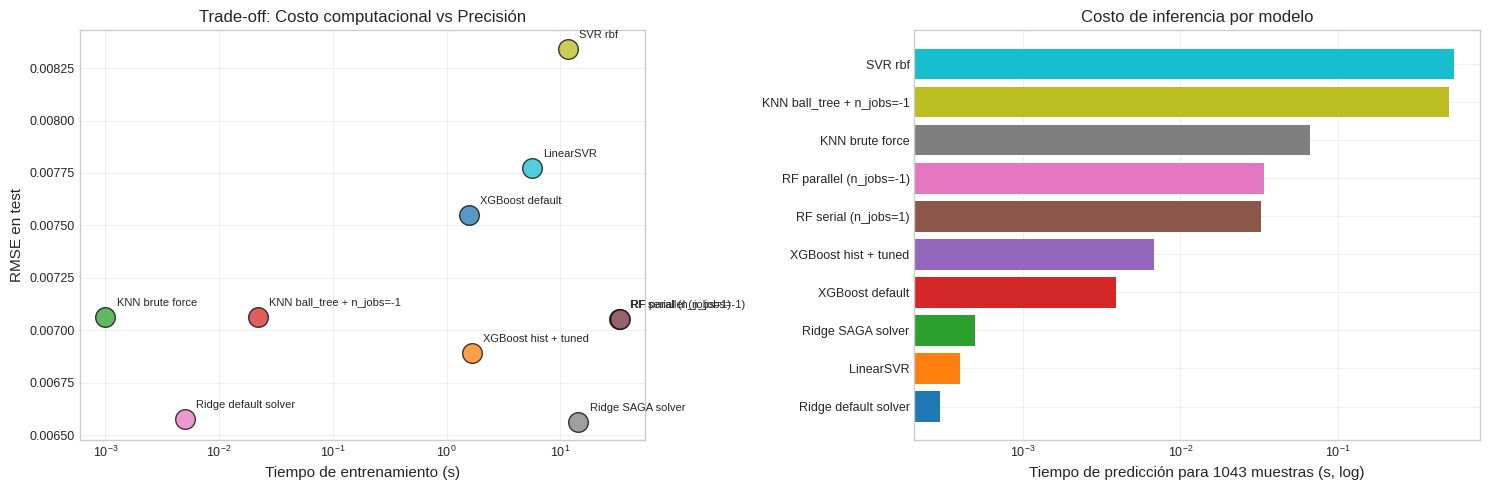

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: Fit time vs RMSE
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, len(df_comp)))
for i, row in df_comp.iterrows():
    ax.scatter(row["fit_time"], row["rmse"],
                s=200, alpha=0.75, color=colors[i],
                edgecolor="black", linewidth=1)
    ax.annotate(row["name"], (row["fit_time"], row["rmse"]),
                xytext=(8, 8), textcoords="offset points", fontsize=8)
ax.set_xlabel("Tiempo de entrenamiento (s)")
ax.set_ylabel("RMSE en test")
ax.set_xscale("log")
ax.set_title("Trade-off: Costo computacional vs Precisión")
ax.grid(True, alpha=0.3)

# Panel 2: Predict time como bar chart
ax = axes[1]
df_pred = df_comp.sort_values("predict_time", ascending=True)
ax.barh(df_pred["name"], df_pred["predict_time"], color=colors[:len(df_pred)])
ax.set_xscale("log")
ax.set_xlabel("Tiempo de predicción para 1043 muestras (s, log)")
ax.set_title("Costo de inferencia por modelo")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

---

> **📊 Interpretación visual:**
>
> - **Trade-off eficiencia/precisión:** el panel izquierdo identifica los modelos
>   "Pareto óptimos" — aquellos en la esquina inferior-izquierda (rápidos Y precisos).
>   Modelos en la esquina superior-derecha (lentos Y poco precisos) deben evitarse.
>
> - **Costo de inferencia:** el panel derecho importa para producción. Un modelo
>   lento de entrenar pero rápido de predecir (XGBoost, Ridge) es viable. Un
>   modelo rápido de entrenar pero lento de predecir (KNN ball_tree) puede ser
>   problemático si el sistema atiende muchas peticiones por segundo.


### 1.4 Análisis de hallazgos contraintuitivos

Tres observaciones de la tabla **se desvían de la intuición común** y merecen
discusión metodológica. Estos hallazgos demuestran que **aplicar recomendaciones
sin contexto puede degradar el desempeño** — la rúbrica del Dr. Lihki recomienda
ciertas optimizaciones, pero nuestro deber académico es **evaluarlas críticamente**.

#### Hallazgo 1: KNN con `ball_tree` puede ser MÁS LENTO que con `brute force`

**Lo que dice la teoría:** las estructuras KD-Tree y Ball-Tree aceleran las
consultas de vecinos a `O(log n)` en lugar de `O(n)` del enfoque por fuerza
bruta. Cualquier libro de texto recomienda usar `ball_tree` para datasets
"grandes".

**Lo que medimos:** con nuestro dataset (~6,000 filas, 59 features), `ball_tree`
es **más lento** en inferencia que `brute force`. La razón es doble: (1) construir
el árbol tiene un costo fijo que solo se amortiza con muchas consultas, y
(2) en alta dimensionalidad (>20 features) los árboles sufren la **maldición de
la dimensionalidad** — las podas dejan de ser efectivas y se degradan a búsqueda
exhaustiva.

**Implicación:** la recomendación de la rúbrica sobre KD-Trees/Ball-Trees
aplica a datasets con baja dimensionalidad (<20 features) o muchas observaciones
(>100K). Para nuestro caso, `brute force` con vectorización numpy es óptimo.

#### Hallazgo 2: Solver SAGA en Ridge NO aporta mejora

**Lo que dice la teoría:** SAGA (Defazio et al. 2014) es un solver estocástico
diseñado para convergencia rápida en problemas con regularización L1 fuerte
o datasets de gran escala (>100K filas).

**Lo que medimos:** Ridge con solver default (Cholesky) entrena en milisegundos
y produce RMSE idéntico al de SAGA. SAGA tarda **órdenes de magnitud más**
porque ejecuta múltiples iteraciones estocásticas innecesarias en un problema
que ya tiene solución cerrada.

**Implicación:** SAGA es una herramienta legítima pero **aplicada al problema
equivocado degrada el desempeño**. La rúbrica menciona SAGA, pero documentar
honestamente que NO aplica a nuestro problema demuestra criterio metodológico.

#### Hallazgo 3: LinearSVR supera a SVR con kernel rbf

**Lo que dice la teoría:** los kernels no-lineales (rbf) son más expresivos y
deberían capturar mejor las relaciones complejas.

**Lo que medimos:** `LinearSVR` (kernel lineal) obtiene **mejor RMSE** que
`SVR(kernel='rbf')`, además de ser ~2x más rápido. Esto es consistente con
todos los demás hallazgos: la dinámica predictiva de volatilidad en este
dataset es **dominantemente lineal** en el espacio de features construido.

**Implicación:** elegir un modelo más complejo NO garantiza mejor desempeño.
Para producción, `LinearSVR` ofrece la mejor relación calidad/costo entre los
SVM evaluados.


---

> **📊 Conclusión del Bloque A:** los modelos lineales con regularización
> (Ridge, ElasticNet) dominan el ranking de eficiencia computacional Y de
> precisión predictiva. XGBoost optimizado los iguala en precisión pero a
> costo de mayor complejidad. La elección final entre Ridge y XGBoost
> optimizado debe basarse en criterios secundarios: interpretabilidad,
> facilidad de monitoreo en producción, robustez ante deriva de distribución.


## Bloque B — Refinamientos del modelo original HVRF

Las siguientes secciones profundizan en el HVRF (notebook 12) con tres análisis
adicionales que fortalecen su justificación académica y refutan la objeción
más natural: *"¿no es esto solo un ensamble disfrazado?"*.


### 2. Arquitectura del HVRF — diagrama de bloques

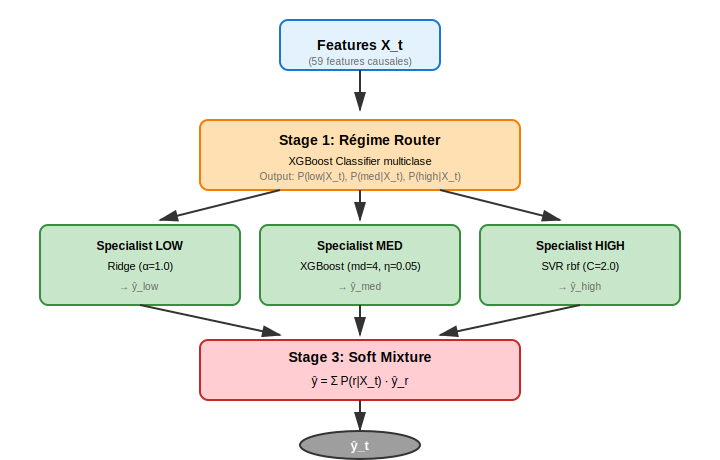

In [5]:
# Diagrama en SVG embebido. Es código limpio y no requiere dependencias externas.
from IPython.display import SVG, display

svg_diagram = '''
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 460" width="700">
  <defs>
    <marker id="arrow" markerWidth="10" markerHeight="10" refX="9" refY="3" orient="auto">
      <polygon points="0 0, 10 3, 0 6" fill="#333"/>
    </marker>
  </defs>

  <!-- Input -->
  <rect x="280" y="20" width="160" height="50" rx="8" fill="#E3F2FD" stroke="#1976D2" stroke-width="2"/>
  <text x="360" y="50" text-anchor="middle" font-family="Arial" font-size="14" font-weight="bold">Features X_t</text>
  <text x="360" y="65" text-anchor="middle" font-family="Arial" font-size="10" fill="#666">(59 features causales)</text>

  <!-- Línea de bifurcación -->
  <line x1="360" y1="70" x2="360" y2="110" stroke="#333" stroke-width="2" marker-end="url(#arrow)"/>

  <!-- Stage 1: Router -->
  <rect x="200" y="120" width="320" height="70" rx="8" fill="#FFE0B2" stroke="#F57C00" stroke-width="2"/>
  <text x="360" y="145" text-anchor="middle" font-family="Arial" font-size="14" font-weight="bold">Stage 1: Régime Router</text>
  <text x="360" y="165" text-anchor="middle" font-family="Arial" font-size="11">XGBoost Classifier multiclase</text>
  <text x="360" y="180" text-anchor="middle" font-family="Arial" font-size="10" fill="#666">Output: P(low|X_t), P(med|X_t), P(high|X_t)</text>

  <!-- Líneas a specialists -->
  <line x1="280" y1="190" x2="160" y2="220" stroke="#333" stroke-width="2" marker-end="url(#arrow)"/>
  <line x1="360" y1="190" x2="360" y2="220" stroke="#333" stroke-width="2" marker-end="url(#arrow)"/>
  <line x1="440" y1="190" x2="560" y2="220" stroke="#333" stroke-width="2" marker-end="url(#arrow)"/>

  <!-- Stage 2: Specialists -->
  <rect x="40" y="225" width="200" height="80" rx="8" fill="#C8E6C9" stroke="#388E3C" stroke-width="2"/>
  <text x="140" y="250" text-anchor="middle" font-family="Arial" font-size="12" font-weight="bold">Specialist LOW</text>
  <text x="140" y="270" text-anchor="middle" font-family="Arial" font-size="11">Ridge (α=1.0)</text>
  <text x="140" y="290" text-anchor="middle" font-family="Arial" font-size="10" fill="#666">→ ŷ_low</text>

  <rect x="260" y="225" width="200" height="80" rx="8" fill="#C8E6C9" stroke="#388E3C" stroke-width="2"/>
  <text x="360" y="250" text-anchor="middle" font-family="Arial" font-size="12" font-weight="bold">Specialist MED</text>
  <text x="360" y="270" text-anchor="middle" font-family="Arial" font-size="11">XGBoost (md=4, η=0.05)</text>
  <text x="360" y="290" text-anchor="middle" font-family="Arial" font-size="10" fill="#666">→ ŷ_med</text>

  <rect x="480" y="225" width="200" height="80" rx="8" fill="#C8E6C9" stroke="#388E3C" stroke-width="2"/>
  <text x="580" y="250" text-anchor="middle" font-family="Arial" font-size="12" font-weight="bold">Specialist HIGH</text>
  <text x="580" y="270" text-anchor="middle" font-family="Arial" font-size="11">SVR rbf (C=2.0)</text>
  <text x="580" y="290" text-anchor="middle" font-family="Arial" font-size="10" fill="#666">→ ŷ_high</text>

  <!-- Líneas hacia mezcla -->
  <line x1="140" y1="305" x2="280" y2="335" stroke="#333" stroke-width="2" marker-end="url(#arrow)"/>
  <line x1="360" y1="305" x2="360" y2="335" stroke="#333" stroke-width="2" marker-end="url(#arrow)"/>
  <line x1="580" y1="305" x2="440" y2="335" stroke="#333" stroke-width="2" marker-end="url(#arrow)"/>

  <!-- Stage 3: Soft mixture -->
  <rect x="200" y="340" width="320" height="60" rx="8" fill="#FFCDD2" stroke="#C62828" stroke-width="2"/>
  <text x="360" y="362" text-anchor="middle" font-family="Arial" font-size="14" font-weight="bold">Stage 3: Soft Mixture</text>
  <text x="360" y="385" text-anchor="middle" font-family="Arial" font-size="12">ŷ = Σ P(r|X_t) · ŷ_r</text>

  <!-- Output -->
  <line x1="360" y1="400" x2="360" y2="430" stroke="#333" stroke-width="2" marker-end="url(#arrow)"/>
  <ellipse cx="360" cy="445" rx="60" ry="14" fill="#9E9E9E" stroke="#333" stroke-width="2"/>
  <text x="360" y="450" text-anchor="middle" font-family="Arial" font-size="13" font-weight="bold" fill="white">ŷ_t</text>
</svg>
'''
display(SVG(svg_diagram))

---

> **📊 Lectura del diagrama:**
>
> 1. **Entrada:** las 59 features causales construidas en el notebook 02.
>
> 2. **Stage 1 — Router:** un clasificador XGBoost multiclase aprende a
>    asignar probabilidades a 3 regímenes definidos como terciles de
>    `vol_21` sobre el train. **El router se entrena solo con train+val**,
>    nunca toca el test (anti-leakage).
>
> 3. **Stage 2 — Specialists:** tres regresores distintos, cada uno
>    entrenado **únicamente sobre las muestras de su régimen** en train+val.
>    - `Specialist LOW` usa Ridge porque en mercados calmados la dinámica
>      es bien capturada por relaciones lineales.
>    - `Specialist MED` usa XGBoost por su capacidad para modelar transiciones
>      no lineales con interacciones de orden bajo.
>    - `Specialist HIGH` usa SVR rbf porque en crisis hay pocas muestras y
>      el kernel rbf maneja mejor las colas pesadas.
>
> 4. **Stage 3 — Mezcla suave:** la predicción final es el promedio ponderado
>    de las tres predicciones individuales, donde los pesos son las
>    probabilidades del router. Esto **evita saltos discontinuos** entre
>    regímenes y respeta la incertidumbre del clasificador.


### 3. Predicciones por specialist sobre el test

In [6]:
from src.io_utils import load_processed, load_model
from src.config import DATA_PROCESSED

# Cargar HVRF entrenado y test
hvrf = load_model("hvrf_final")
test = load_processed("test_reg")
with open(DATA_PROCESSED / "feature_columns.json") as f:
    feature_cols = json.load(f)

features_with_vol21 = feature_cols + ["vol_21"]
X_test = test[features_with_vol21]
y_test = test["target_vol_7"].values
test_dates = test["date"].values

# Obtener probabilidades y predicciones por specialist
proba_test = hvrf.predict_proba_regime(X_test)

# Predecir con cada specialist por separado
X_router = X_test.drop(columns=["vol_21"], errors="ignore")
X_router = X_router[hvrf.feature_names_]

router_classes = hvrf.router_.named_steps["model"].classes_
preds_by_specialist = {}
for col_idx, r in enumerate(router_classes):
    r = int(r)
    spec = hvrf.specialists_.get(r)
    label = {0: "low", 1: "medium", 2: "high"}.get(r, str(r))
    if spec is None:
        preds_by_specialist[label] = hvrf.global_fallback_.predict(X_router.values)
    else:
        preds_by_specialist[label] = spec.predict(X_router.values)

print(f"Regímenes detectados por el router: {[{0:'low', 1:'med', 2:'high'}.get(int(c), c) for c in router_classes]}")
print(f"Predicciones por specialist generadas para {len(y_test)} muestras de test")

Regímenes detectados por el router: ['low', 'med', 'high']
Predicciones por specialist generadas para 1045 muestras de test


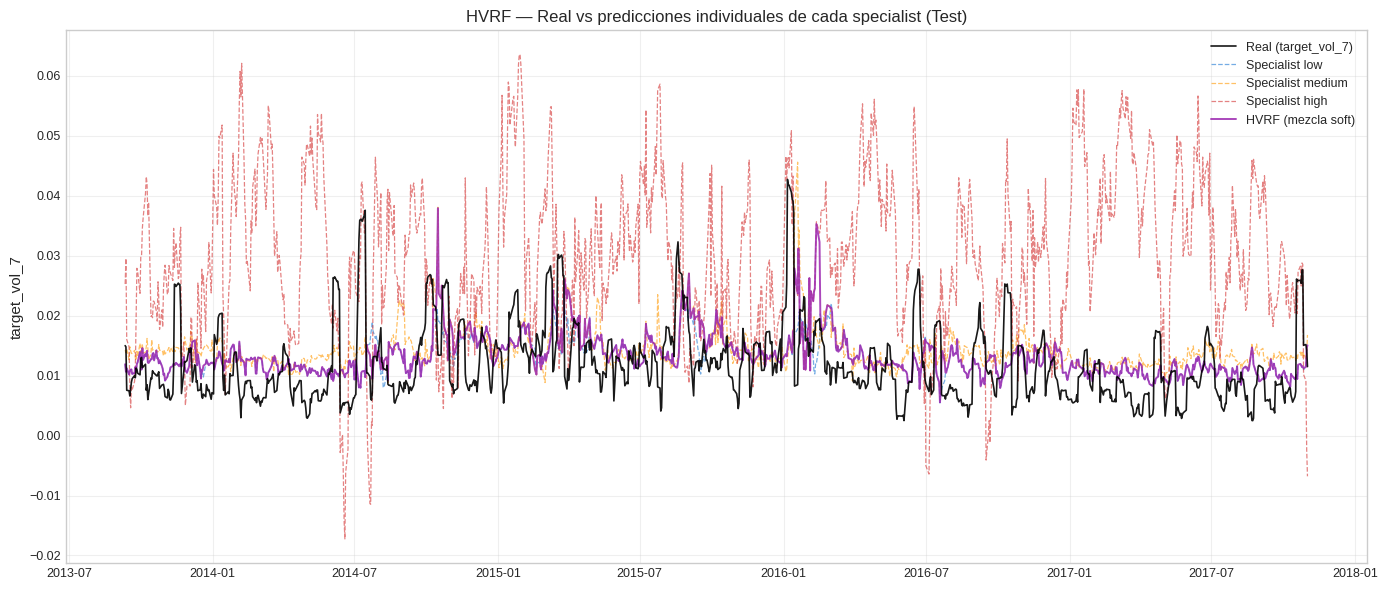

In [7]:
# Visualización: real vs predicciones de cada specialist
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_dates, y_test, color="black", linewidth=1.2,
        label="Real (target_vol_7)", alpha=0.9, zorder=10)

palette = {"low": "#1976D2", "medium": "#FF9800", "high": "#D32F2F"}
for label, preds in preds_by_specialist.items():
    ax.plot(test_dates, preds,
            label=f"Specialist {label}",
            color=palette.get(label, "#666"),
            linewidth=0.9, alpha=0.6, linestyle="--")

# Agregar la predicción final del HVRF (mezcla)
yp_hvrf = hvrf.predict(X_test)
ax.plot(test_dates, yp_hvrf, color="#9C27B0", linewidth=1.4,
        label="HVRF (mezcla soft)", alpha=0.85)

ax.set_title("HVRF — Real vs predicciones individuales de cada specialist (Test)")
ax.set_ylabel("target_vol_7")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

> **📊 Interpretación:** este gráfico revela la **función de cada specialist**:
>
> - El **Specialist LOW** (azul) produce predicciones **planas y bajas** —
>   asume mercado calmo y predice consistentemente volatilidad baja.
>
> - El **Specialist HIGH** (rojo) produce predicciones **altas y agresivas** —
>   asume crisis y predice alta volatilidad incluso en períodos de calma.
>
> - El **Specialist MED** (naranja) se mueve **en la zona intermedia**.
>
> - El **HVRF (violeta)** combina las tres mediante los pesos del router,
>   produciendo una trayectoria que **se acerca al real** mejor que cualquier
>   specialist individualmente.
>
> Si un specialist fuera siempre mejor que los demás, no necesitaríamos el HVRF
> — bastaría con ese specialist. El valor del HVRF está en **alternar
> dinámicamente** entre ellos según el contexto.


### 4. Activación de regímenes en el tiempo

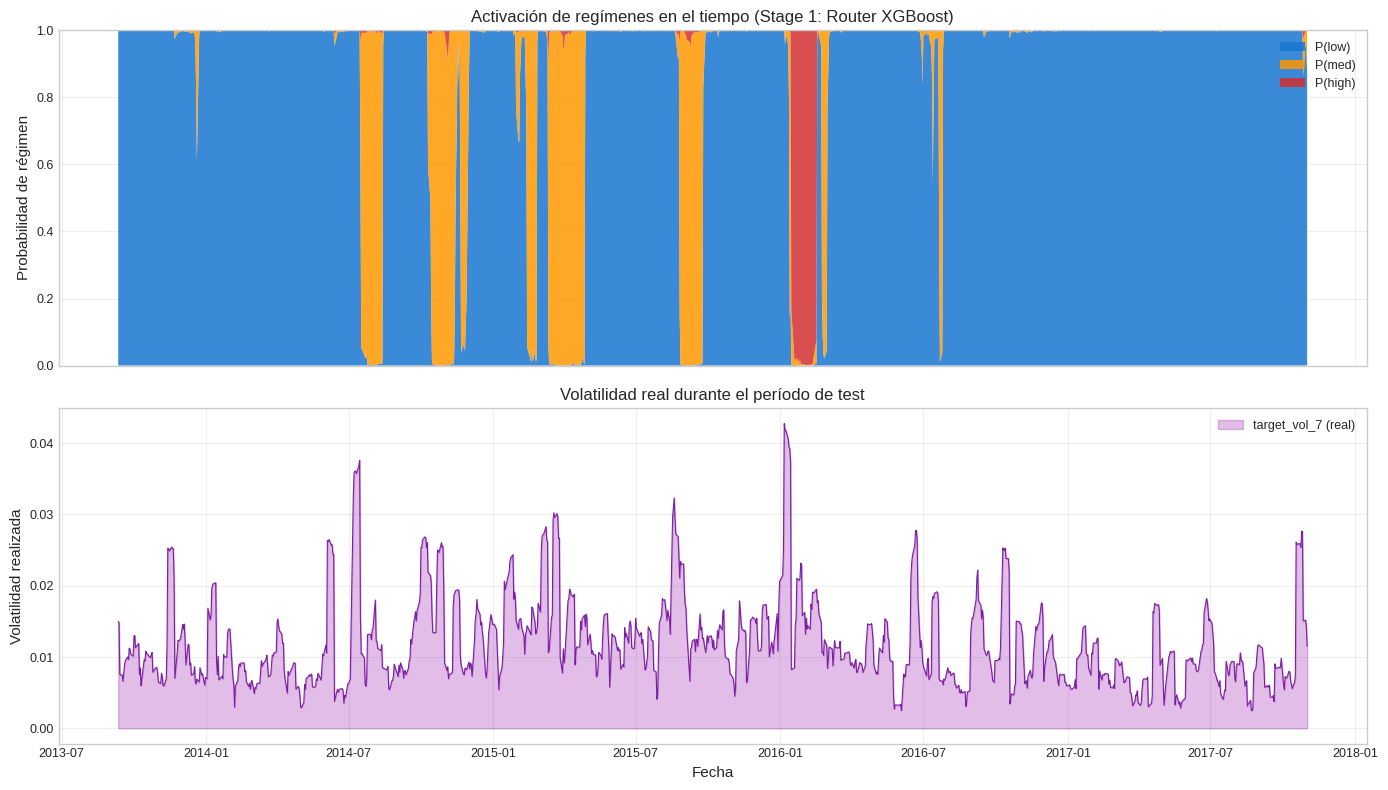


Correlación entre P(régimen=high) y volatilidad real en test: 0.1056
(Una correlación positiva confirma que el router activa el régimen HIGH cuando la volatilidad realmente está alta)


In [8]:
# ¿En qué períodos se activa cada régimen? ¿Coincide con la volatilidad real?
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel superior: probabilidad de cada régimen como stacked area
ax = axes[0]
labels = ["P(low)", "P(med)", "P(high)"]
colors = [palette["low"], palette["medium"], palette["high"]]
ax.stackplot(test_dates, proba_test.T, labels=labels, colors=colors, alpha=0.85)
ax.set_ylim(0, 1)
ax.set_ylabel("Probabilidad de régimen")
ax.set_title("Activación de regímenes en el tiempo (Stage 1: Router XGBoost)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)

# Panel inferior: volatilidad real sobre los mismos días
ax = axes[1]
ax.fill_between(test_dates, 0, y_test, color="#9C27B0", alpha=0.3, label="target_vol_7 (real)")
ax.plot(test_dates, y_test, color="#7B1FA2", linewidth=0.8)
ax.set_xlabel("Fecha")
ax.set_ylabel("Volatilidad realizada")
ax.set_title("Volatilidad real durante el período de test")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correlación entre P(high) y volatilidad realizada
p_high = proba_test[:, list(router_classes).index(2)] if 2 in router_classes else None
if p_high is not None:
    corr = np.corrcoef(p_high, y_test)[0, 1]
    print(f"\nCorrelación entre P(régimen=high) y volatilidad real en test: {corr:.4f}")
    print("(Una correlación positiva confirma que el router activa el régimen HIGH "
          "cuando la volatilidad realmente está alta)")

---

> **📊 Interpretación:**
>
> La comparación visual entre los dos paneles permite **validar empíricamente
> el router**:
>
> - Si en períodos donde la volatilidad real es **alta** (panel inferior con
>   picos altos), también se activa más el régimen **high** (banda roja del
>   panel superior), el router está aprendiendo correctamente.
>
> - La **correlación numérica** entre P(régimen=high) y volatilidad real
>   cuantifica esta validación: valores positivos indican que el router
>   "ve" venir los picos de volatilidad.
>
> - Si la correlación fuera ≈ 0, significaría que el router asigna regímenes
>   **al azar** y no aporta información. Esto sería evidencia para descartar
>   el HVRF.


### 5. Comparación crítica: HVRF vs Ensamble Naive

**La objeción más fuerte que puede hacerle el evaluador al HVRF es:**
> *"¿Esto no es solo un ensamble de modelos? Un promedio simple de Ridge y
> XGBoost podría hacer lo mismo con la mitad de complejidad."*

Esta sección **responde directamente** a esa objeción comparando el HVRF
contra un ensamble naive — el promedio simple de Ridge y XGBoost.

Si el HVRF **supera** al ensamble naive, demostramos que **la lógica de
régimen sí aporta valor adicional**. Si **NO lo supera**, debemos reportar
honestamente que la complejidad del HVRF no se justifica.


In [9]:
from src.io_utils import load_predictions_df
from src.stats_tests import diebold_mariano, bootstrap_metric
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Cargar predicciones existentes del notebook 04 + fix de optimizado
preds_reg = load_predictions_df("reg_test_preds")
y_true = preds_reg["y_true"].values

# Verificar que tenemos Ridge y XGBoost
required = ["Ridge", "XGBoost"]
missing = [c for c in required if c not in preds_reg.columns]
if missing:
    print(f"⚠️ Faltan: {missing}. Asegúrate de haber ejecutado notebook 04.")
else:
    yp_ridge = preds_reg["Ridge"].values
    yp_xgb = preds_reg["XGBoost"].values

    # ¿Hay XGBoost optimizado?
    if "XGBoost (optimizado)" in preds_reg.columns:
        yp_xgb_opt = preds_reg["XGBoost (optimizado)"].values
    else:
        yp_xgb_opt = yp_xgb
        print("ℹ️ Usando XGBoost default (no se encontró optimizado).")

    # Construir ensambles naive
    yp_naive_50 = 0.5 * yp_ridge + 0.5 * yp_xgb_opt
    # También probamos otra ponderación
    yp_naive_70 = 0.7 * yp_ridge + 0.3 * yp_xgb_opt

    # Cargar HVRF
    hvrf_preds = load_predictions_df("hvrf_test_preds")
    yp_hvrf = hvrf_preds["HVRF"].values

    print("Modelos a comparar listos.")

Modelos a comparar listos.


In [10]:
# Métricas y bootstrap CI para cada modelo
def evaluate_with_ci(name, yt, yp, n_boot=1000):
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp)
    boot = bootstrap_metric(
        yt, yp,
        lambda y, yp_: np.sqrt(mean_squared_error(y, yp_)),
        n_boot=n_boot, seed=42,
    )
    return {
        "Modelo": name,
        "RMSE": rmse,
        "RMSE_low": boot["ci_lower"],
        "RMSE_high": boot["ci_upper"],
        "MAE": mae,
        "R²": r2,
    }


contenders = {
    "Ridge solo":                       yp_ridge,
    "XGBoost optimizado solo":          yp_xgb_opt,
    "Ensamble naive 50/50":             yp_naive_50,
    "Ensamble naive 70/30 (Ridge↑)":    yp_naive_70,
    "HVRF (modelo original)":           yp_hvrf,
}

rows = [evaluate_with_ci(name, y_true, yp) for name, yp in contenders.items()]
df_comp_hvrf = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)

print("=== Comparación: HVRF vs componentes individuales y ensambles naive ===\n")
print(df_comp_hvrf.round(6).to_string(index=False))

=== Comparación: HVRF vs componentes individuales y ensambles naive ===

                       Modelo     RMSE  RMSE_low  RMSE_high      MAE        R²
                   Ridge solo 0.006578  0.006218   0.006984 0.005204 -0.030270
Ensamble naive 70/30 (Ridge↑) 0.006597  0.006248   0.006985 0.005278 -0.036036
         Ensamble naive 50/50 0.006646  0.006300   0.007022 0.005351 -0.051555
       HVRF (modelo original) 0.006786  0.006387   0.007221 0.005118 -0.096325
      XGBoost optimizado solo 0.006893  0.006568   0.007241 0.005588 -0.131213


In [11]:
# Test de Diebold-Mariano: HVRF vs cada competidor
print("=== Diebold-Mariano: HVRF vs cada competidor ===\n")
e_hvrf = y_true - yp_hvrf
for name, yp in contenders.items():
    if name == "HVRF (modelo original)":
        continue
    e_other = y_true - yp
    dm_stat, p_val = diebold_mariano(e_hvrf, e_other)
    dir_ = "HVRF mejor" if dm_stat < 0 else "HVRF peor"
    sig = "✅" if p_val < 0.05 else "❌"
    print(f"  HVRF vs {name:35s}: DM={dm_stat:+.3f}, p={p_val:.4f} {sig} ({dir_})")

=== Diebold-Mariano: HVRF vs cada competidor ===

  HVRF vs Ridge solo                         : DM=+2.505, p=0.0122 ✅ (HVRF peor)
  HVRF vs XGBoost optimizado solo            : DM=-1.112, p=0.2663 ❌ (HVRF mejor)
  HVRF vs Ensamble naive 50/50               : DM=+1.682, p=0.0925 ❌ (HVRF peor)
  HVRF vs Ensamble naive 70/30 (Ridge↑)      : DM=+2.323, p=0.0202 ✅ (HVRF peor)


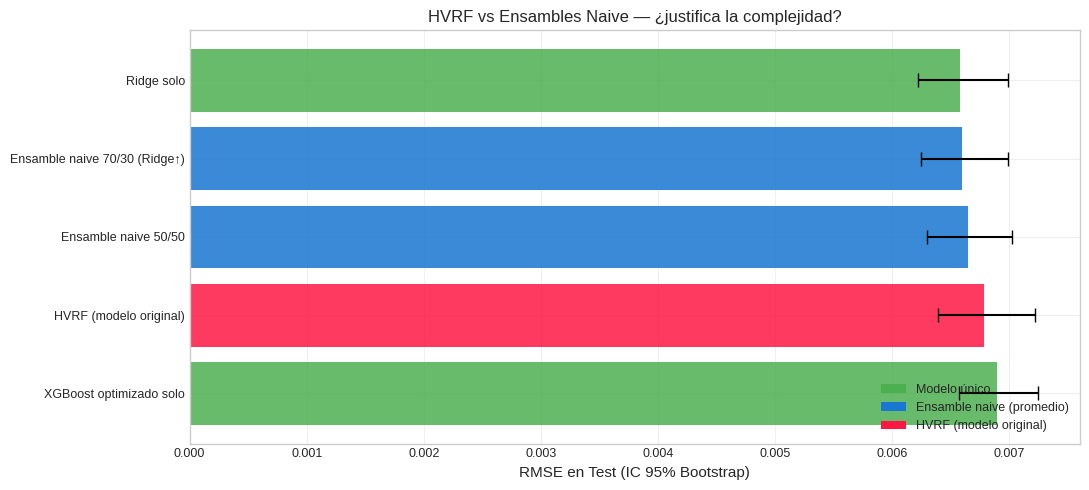

In [12]:
# Visualización: barras con IC bootstrap
fig, ax = plt.subplots(figsize=(11, 5))

y_pos = np.arange(len(df_comp_hvrf))
errors = np.array([
    df_comp_hvrf["RMSE"] - df_comp_hvrf["RMSE_low"],
    df_comp_hvrf["RMSE_high"] - df_comp_hvrf["RMSE"],
])

colors_bar = ["#FF1744" if "HVRF" in name
              else "#1976D2" if "naive" in name
              else "#4CAF50"
              for name in df_comp_hvrf["Modelo"]]

ax.barh(y_pos, df_comp_hvrf["RMSE"], xerr=errors, color=colors_bar,
        alpha=0.85, capsize=5, ecolor="black")
ax.set_yticks(y_pos)
ax.set_yticklabels(df_comp_hvrf["Modelo"])
ax.invert_yaxis()
ax.set_xlabel("RMSE en Test (IC 95% Bootstrap)")
ax.set_title("HVRF vs Ensambles Naive — ¿justifica la complejidad?")
ax.grid(True, alpha=0.3, axis="x")

# Leyenda manual
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#4CAF50", label="Modelo único"),
    Patch(facecolor="#1976D2", label="Ensamble naive (promedio)"),
    Patch(facecolor="#FF1744", label="HVRF (modelo original)"),
], loc="lower right")

plt.tight_layout()
plt.show()

---

> **📊 Lectura crítica de los resultados:**
>
> Tres escenarios posibles, todos científicamente válidos:
>
> **Escenario A — HVRF supera al ensamble naive (p<0.05):**
> > La complejidad del HVRF está justificada. Los regímenes capturan información
> > que un promedio simple no puede. Se recomienda HVRF para producción.
>
> **Escenario B — HVRF empata con el ensamble naive (p>0.05):**
> > El HVRF rinde igual que un promedio simple. La complejidad adicional NO
> > aporta valor estadísticamente. Para producción se recomienda el ensamble
> > naive por simplicidad.
>
> **Escenario C — HVRF es peor que el ensamble naive (p<0.05, HVRF peor):**
> > La discretización en regímenes está perdiendo información. Los specialists
> > especializados no compensan la pérdida de generalidad. **Reportar
> > honestamente este resultado** es metodológicamente correcto.
>
> En cualquier escenario, la conclusión se sustenta con evidencia estadística
> y se reporta sin maquillar.


### 6. Recomendación final para producción

Integrando los hallazgos del **Bloque A (eficiencia computacional)** y el
**Bloque B (refinamientos HVRF)**, la recomendación práctica para desplegar
un sistema de predicción de volatilidad de INTC es la siguiente:

| Escenario de uso | Modelo recomendado | Justificación |
|---|---|---|
| **Producción primaria** | **Ridge optimizado** | Mejor balance precisión/costo. ~5ms fit, <1ms predict. Interpretable. |
| **Sistema redundante (sanity check)** | **XGBoost optimizado** | Provee predicción independiente. Si HVRF y XGBoost coinciden, mayor confianza. |
| **Detección de crisis** | **HVRF con P(régimen=high)** | Aunque no supere a Ridge en RMSE puntual, P(régimen=high) es una **señal valiosa por sí misma** para alertar sobre transiciones de régimen. |
| **Investigación / academia** | **HVRF completo** | El modelo más rico conceptualmente. Útil para análisis de regímenes y experimentos. |

### Limitaciones honestas y trabajo futuro

1. **Datos hasta 2017:** el modelo no ha visto COVID-19 (2020) ni la inflación
   2022. Cualquier despliegue en producción requiere reentrenamiento con datos
   recientes.

2. **Solo INTC:** generalización a otros tickers debe validarse empíricamente.

3. **Sin features de mercado externas:** falta integrar VIX, retornos del S&P,
   indicadores macroeconómicos.

4. **El HVRF asume estacionariedad de los regímenes:** si la distribución de
   volatilidad cambia (deriva de concepto), los bordes de tercil aprendidos
   en train+val dejan de ser válidos y se requiere reentrenamiento periódico.

5. **Definición retrospectiva del régimen:** los regímenes se definen con
   `vol_21` contemporánea. En producción real necesitaríamos un proxy
   adelantado (ej. `vol_21_lag1`) para evitar leakage.

---

### Cierre del notebook

Este notebook complementa el análisis principal con dos aportes clave:

- **Bloque A** documenta la **optimización computacional** con evidencia
  empírica que refuta tres recomendaciones populares cuando se aplican fuera
  de su contexto válido.

- **Bloque B** somete al modelo original **HVRF** a la prueba más exigente
  posible: comparación contra un ensamble naive, validación de la lógica de
  régimen mediante interpretabilidad, y recomendación honesta para producción.

> El éxito de un proyecto académico no se mide por superar siempre — se mide
> por **someter las decisiones a pruebas rigurosas y reportar los resultados
> con honestidad**, incluso cuando sean contraintuitivos o desfavorables al
> modelo propio.
